# Churn

La retención de clientes es un factor clave en la rentabilidad de cualquier empresa, ya que el costo de adquisición de nuevos clientes suele ser significativamente mayor que el de mantener los existentes.

En este proyecto se desarrolla un modelo de machine learning orientado a predecir la probabilidad de churn, entendiendo churn como la pérdida o abandono del cliente. A través del análisis de variables comportamentales y transaccionales, se busca identificar clientes en riesgo y habilitar estrategias proactivas de retención.


## Descripcion de Variables.
Variable objetivo:

* 1 = Churn (Cliente con posibilidad de abandono)
* 0 = No Churn (Cliente retenido)

* gender = Género del cliente (Male / Female)

* SeniorCitizen = Indica si el cliente es adulto mayor (1 = Sí, 0 = No)

* Partner = Si el cliente tiene pareja (Yes / No)

* Dependents = Si el cliente tiene dependientes (Yes / No)

* tenure = Tiempo (en meses) que el cliente lleva con la empresa.

* PhoneService = Si tiene servicio telefónico

* MultipleLines = Si tiene múltiples líneas telefónicas

* InternetService = Tipo de servicio de internet (DSL/Fiber optic /No)

* OnlineSecurity = Seguridad en línea

* OnlineBackup = Respaldo en la nube

* DeviceProtection = Protección de dispositivos

* TechSupport = Soporte técnico

* StreamingTV = Servicio de TV

* StreamingMovies = Servicio de películas

* Contract = Tipo de contrato. (Month-to-month /One year /Two year)

* PaperlessBilling = Facturación digital.

* PaymentMethod =Método de pago. (Electronic check / Mailed check / Bank transfer / Credit card)

* MonthlyCharges = Cargo mensual del cliente

* TotalCharges = Total pagado por el cliente



# Las variables incluyen características demográficas, servicios contratados, tipo de contrato y comportamiento de facturación, lo que permite analizar el churn desde múltiples dimensiones: comportamiento del cliente, nivel de engagement y factores económicos.

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pycparser.ply.cpp import Preprocessor
from sklearn.metrics import make_scorer
from sklearn.utils import shuffle
from streamlit import header
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score,log_loss, make_scorer
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_columns', None)

In [28]:
df = pd.read_csv(r'C:\Users\jabes\Desktop\PORTAFOLIO CIENTIFICO DE DATOS\CHURN\playground-series-s6e3\train.csv')
df.drop(columns='id', inplace=True)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [29]:
print(f"{df.info()}")
print('*=' * 30)
print(f"{df.isna().sum()}")
print('/n *=' * 30)
print(f"{df.isnull().sum()}")
print('*='*30)
print(f"{df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

* En el DataSet no existen Null's y ni Nan, tenemos muchas variables discretas no numericas las mismas requeriran transformacion, algunas binarias.

# Iniciando EDA

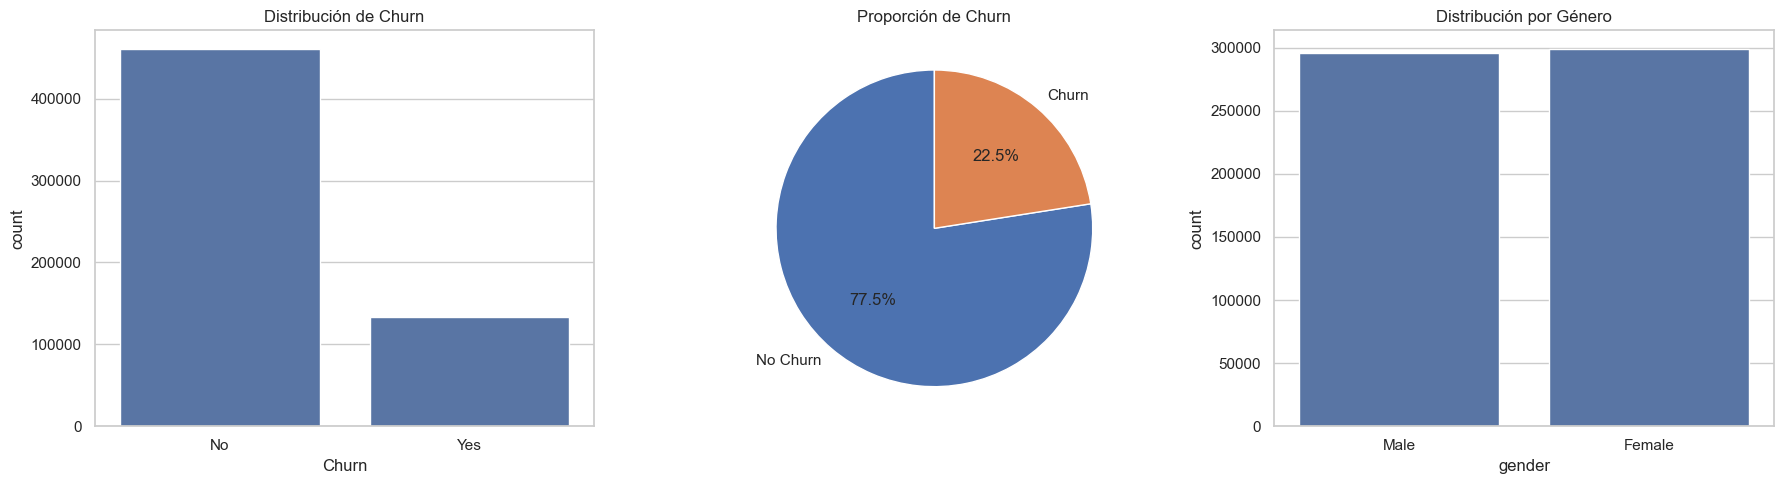

Churn
No     460377
Yes    133817
Name: count, dtype: int64
******************************
gender
Female    50.276172
Male      49.723828
Name: proportion, dtype: float64


In [30]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Churn
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Distribución de Churn')


# Pie Chart (Churn)
churn_counts = df['Churn'].value_counts()
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción de Churn')


# Género

sns.countplot(x='gender', data=df, ax=axes[2])
#axes[2].set_yscale('log')
axes[2].set_title('Distribución por Género')

# Ajustar espacios
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print('**'*15)
print(df['gender'].value_counts(normalize=True)*100)

* El dataset presenta desbalance (22.5% churn vs 77.5% no churn), lo cual deberá considerarse en el modelado.

## Describe

In [31]:
def describe_modif(df):
    num_df = df.select_dtypes(include='number')
    desc = num_df.describe()
    desc.loc['count ceros'] = (num_df == 0).sum()
    desc.loc['count negativos'] = (num_df < 0).sum()
    desc.loc['count null'] = num_df.isna().sum()
    desc.loc['pct ceros'] = (num_df == 0).mean()
    desc.loc['pct negativos'] = (num_df < 0).mean()
    desc.loc['pct nulls'] = num_df.isna().mean()
    desc.loc['Coef. Variacion'] = desc.loc['std'] / desc.loc['mean']
    q1 = desc.loc['25%']
    q3 = desc.loc['75%']
    iqr = q3 - q1
    desc.loc['IQR'] = iqr
    outliers = ((num_df < (q1 - 1.5 * iqr))|(num_df > (q3 + 1.5 * iqr))).sum()
    desc.loc['Conteo de Outliers'] = outliers
    desc.loc['Asimetria'] = num_df.skew()
    percentiles = [0, 0.25,0.50, 0.75, 0.90,0.97, 0.98, 0.99,1]
    for p in percentiles:
        desc.loc[f'P{int(p*100)}'] = num_df.quantile(p)
    desc = desc.drop(index=['min','25%','50%','75%', 'max'])
    return desc.round(2)

describe_modif(df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00,594194.00
mean,0.11,36.58,65.87,2494.38
std,0.32,25.06,31.07,2353.92
count ceros,526395.00,0.00,0.00,0.00
count negativos,0.00,0.00,0.00,0.00
count null,0.00,0.00,0.00,0.00
pct ceros,0.89,0.00,0.00,0.00
pct negativos,0.00,0.00,0.00,0.00
pct nulls,0.00,0.00,0.00,0.00
Coef. Variacion,2.79,0.69,0.47,0.94


# Distribucion de Variables Numericas.

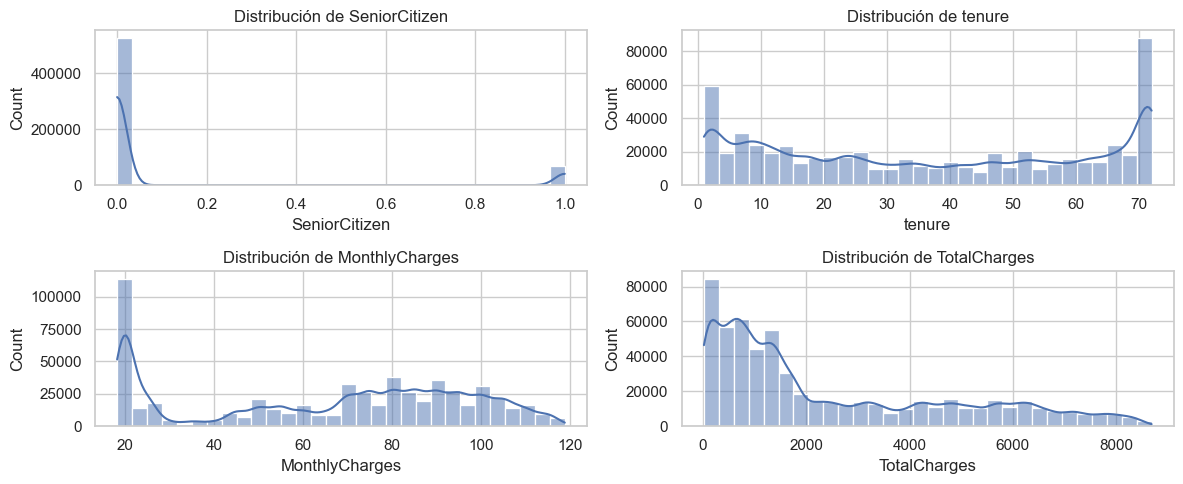

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12,5))

numerical_col = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

for i, col in enumerate(numerical_col):
    row = i // 2
    col_idx = i % 2

    sns.histplot(df[col], bins=30, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

# Observaciones Variables Numericas:

* La variable **SeniorCitizen** es una variable binaria, la cual indica que tenemos una poblacion en su mayoria joven.

* En **MonthlyCharges** confirmo la presencia de algunos bayes y Outliers, podria monstrar algun patron de subcripciones aumento de subscripciones en meses especificos.

* En **TotalCharges** se muestra una grafica decreciente con una fuerte concentracion de 0 a 1900 USD, cabe destacar que esta variable es medida en USD, tambien podria indicar que algunos clientes se atrasan levemente.

* En **Ternure** confirmo la existencia de Outliers los mismos indican una retencion balanceada por clientes viejos mostrando clientes que tienen mas de 70 meses con el servicio contratado, pero tambien muestra una gran masa de clientes que son nuevos y se tendria que buscar los puntos fuertes para hacer que duren en el tiempo.

# Distribucion de Variables Categoricas.

In [33]:
categorical_cols= df.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["Churn", "gender"]]

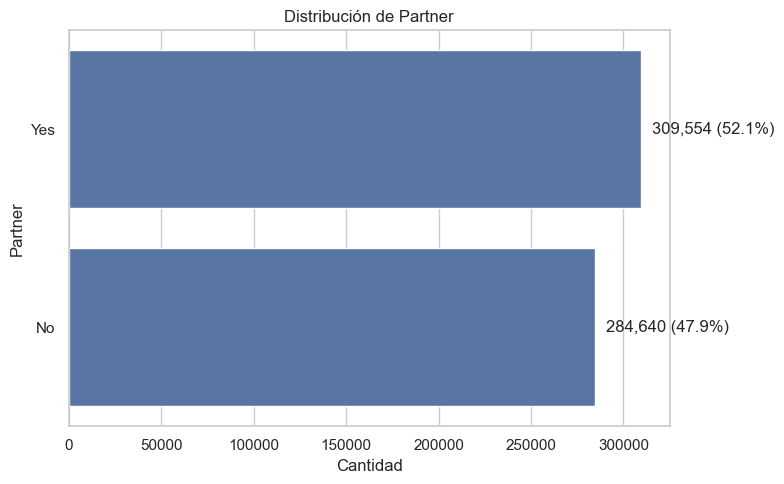

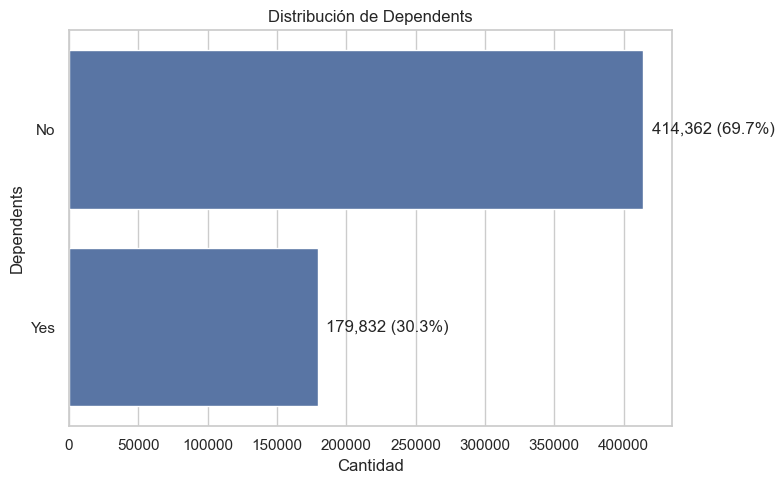

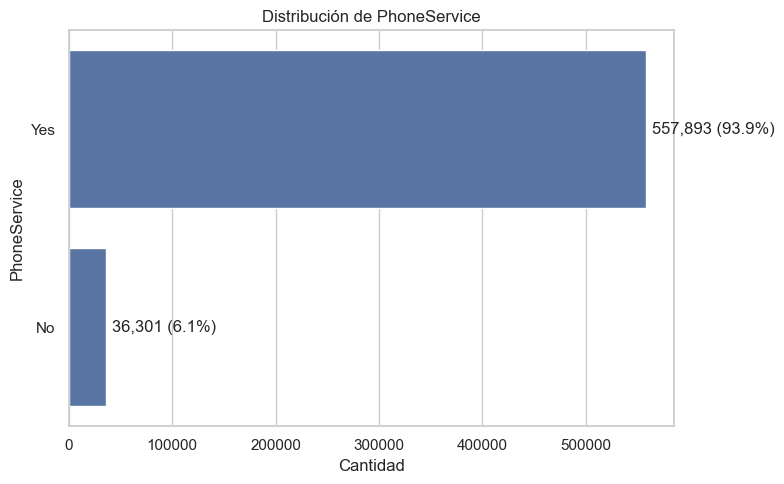

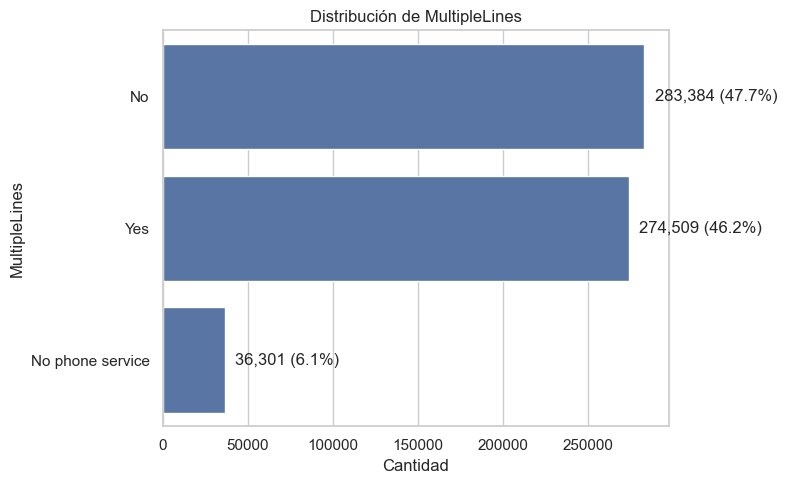

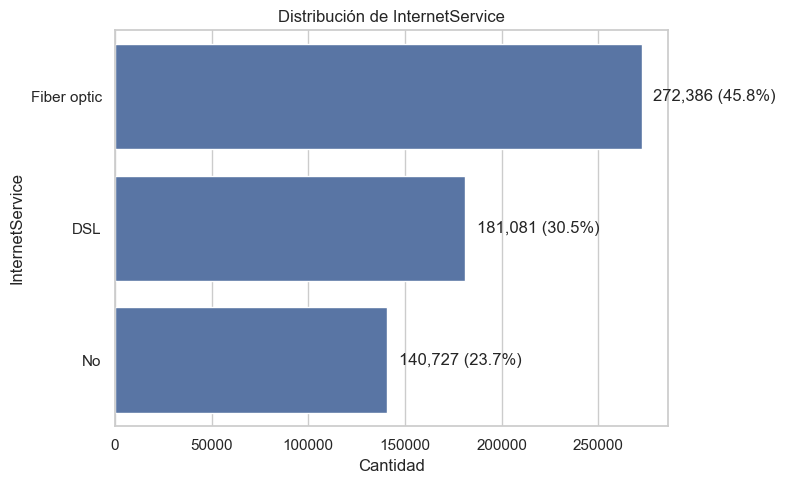

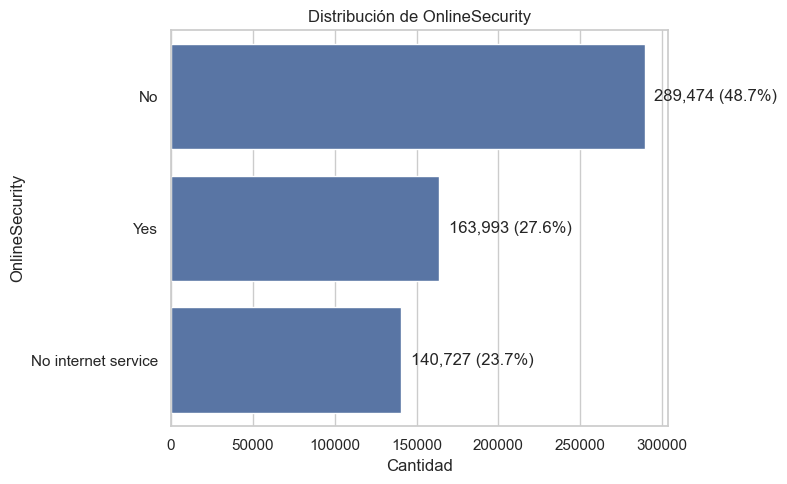

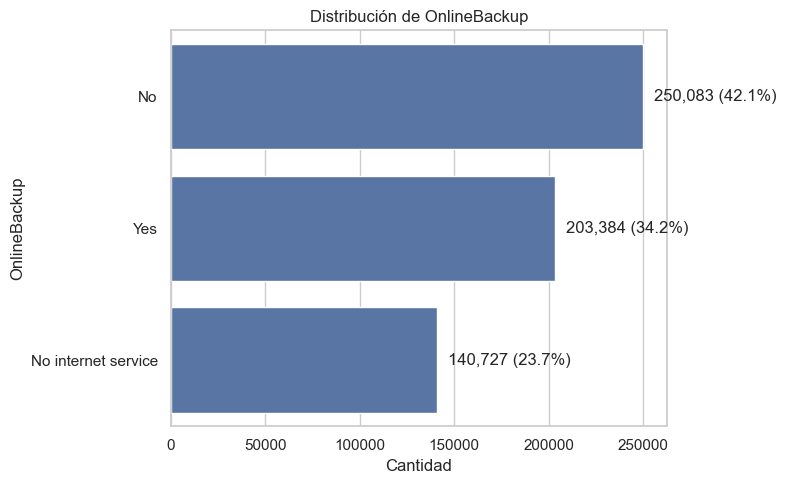

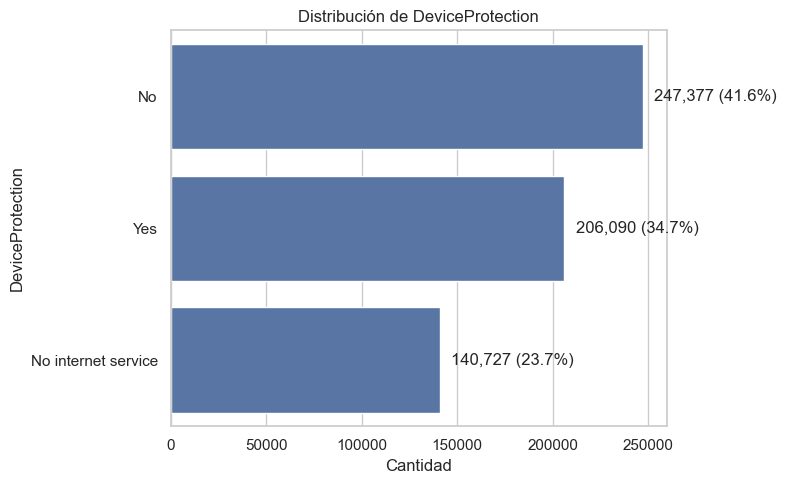

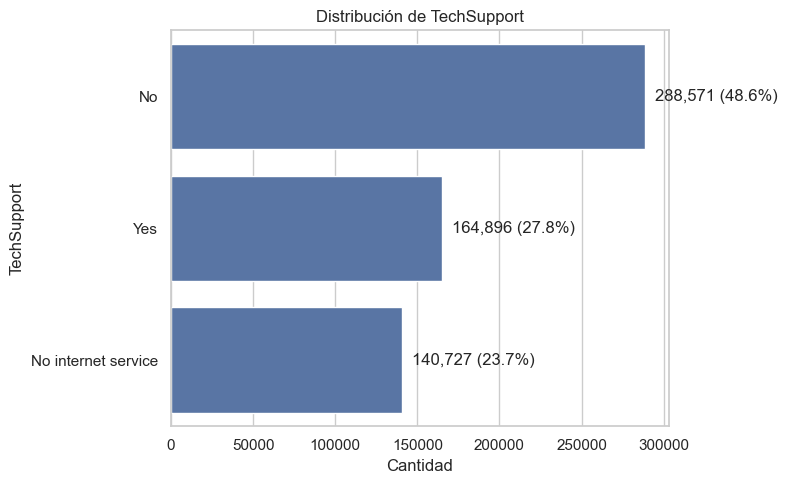

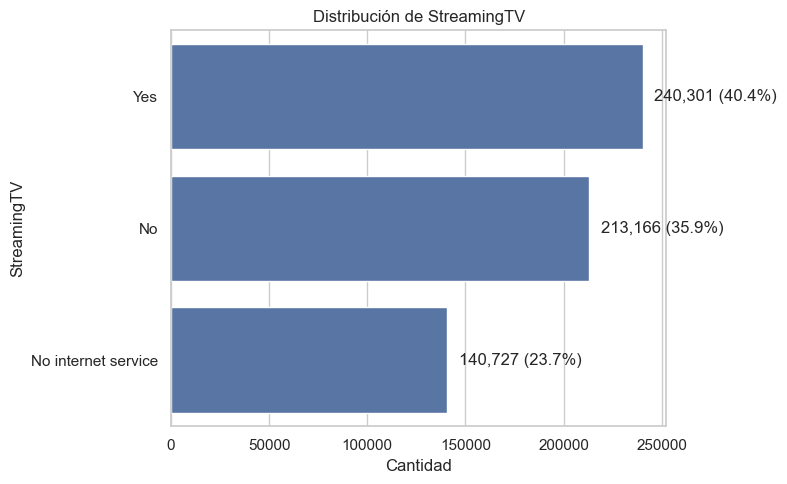

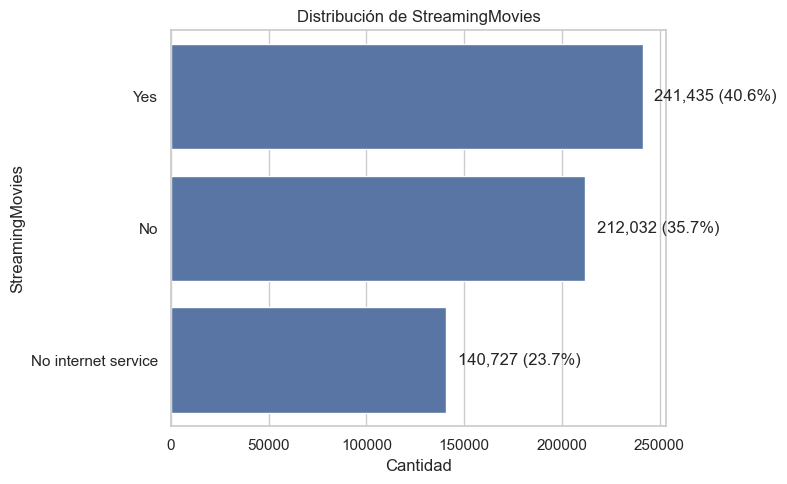

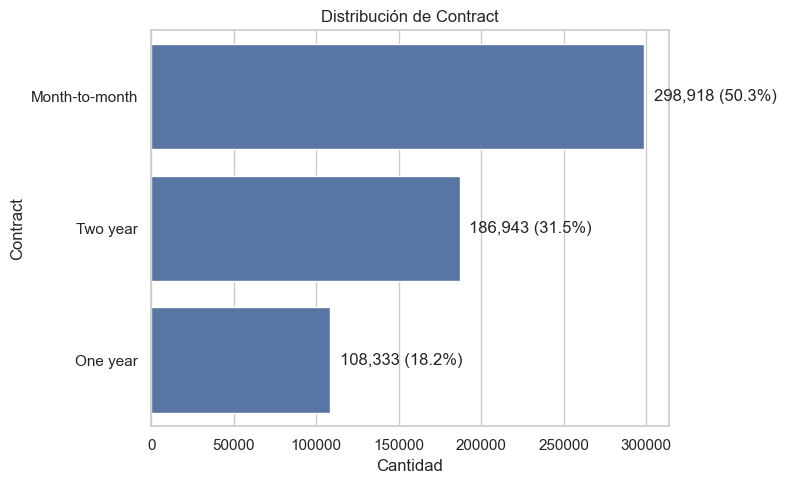

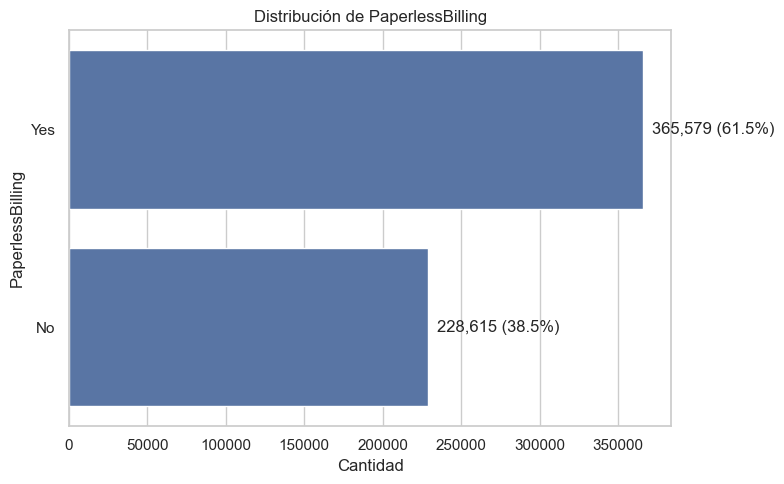

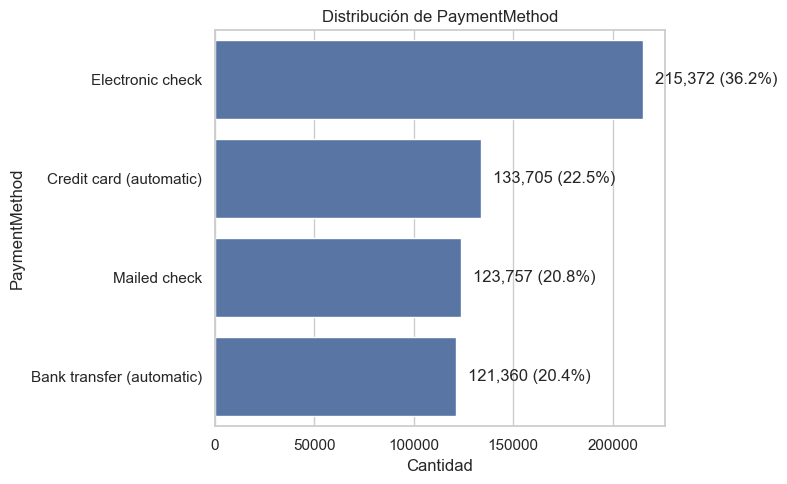

In [34]:
for col in categorical_cols:
    plt.figure(figsize=(8,5))

    # Conteo
    counts = df[col].value_counts()
    total = len(df)

    # Crear barplot horizontal
    ax = sns.barplot(x=counts.values, y=counts.index)

    # Agregar labels con % y count
    for i, v in enumerate(counts.values):
        pct = (v / total) * 100
        ax.text(v + (total * 0.01), i, f'{v:,} ({pct:.1f}%)', va='center')

    plt.title(f'Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Observaciones de Variables Categóricas

* **Churn:** Se observa un fuerte desbalance en las clases, notando que el 22.5% de la población corresponde a clientes que abandonan el servicio brindado.
* **PaymentMethod:** El método de pago con mayor uso es **Electronic Check**, pero la utilización de los otros canales de pago (**Credit Card (automatic)**, **Bank Transfer**, **Mailed Check**) da indicios de que tenemos clientes que pertenecen a una población menos madura.
* **PaperlessBilling:** Más del 60% de los clientes tienen facturación digital. Sería interesante analizar el comportamiento de esta variable frente al **Churn**.
* **Contract:** Más del 50.3% de los clientes utilizan contratación mes a mes, lo que sugiere que son productos de suscripción. También se observa que el 31.5% de la clientela tiene un contrato de 2 años, indicando que podrían ser empresas.
* **StreamingMovies:** Esta variable confirma claramente que es una población relativamente joven. También levanta sospechas el hecho de que el 23.7% no tiene servicio de internet.
* **DeviceProtection:** Este servicio no es muy demandado, solo el 37.7% de la población lo tiene, mientras que el 23.7% muestra que no tiene internet.
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, InternetService:** Todas estas variables tienen algo en común que es una constante interesante: el 23.7% de su población no tiene suscrito el servicio de internet. Esto da a entender que existe una parte de la población que carece del servicio base, o bien, es una población madura que no presenta necesidad de este.
* **PhoneService:** El 94% de la población presenta servicio de teléfono.
* **gender:** La distribución entre géneros es normal y balanceada.
* **MultipleLines:** Más del 46% de los clientes poseen múltiples líneas de servicio contratado. Sería bueno analizar esta distribución con respecto a **Churn**.

# Analisis bivariado.

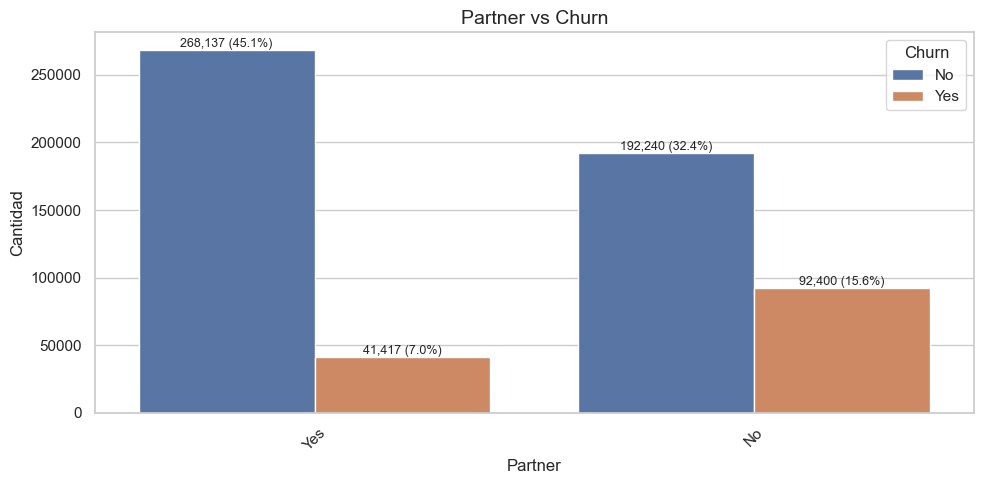

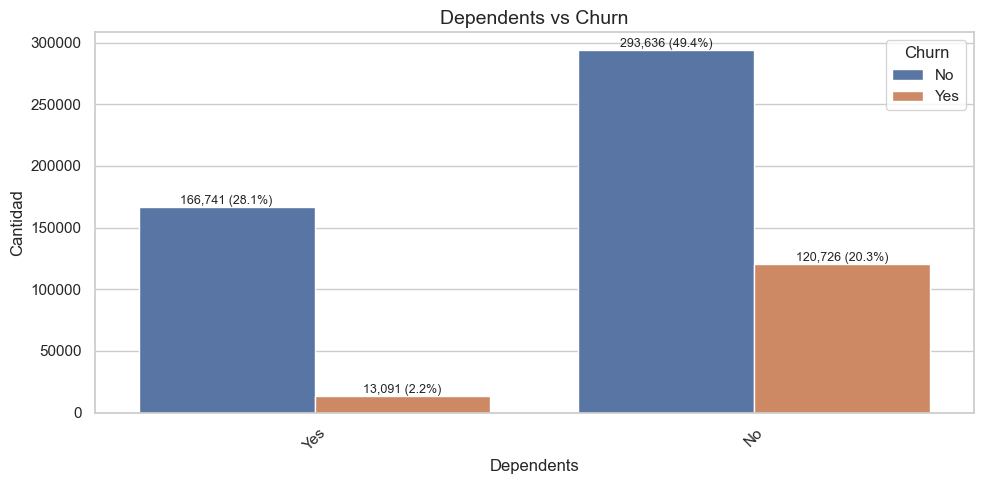

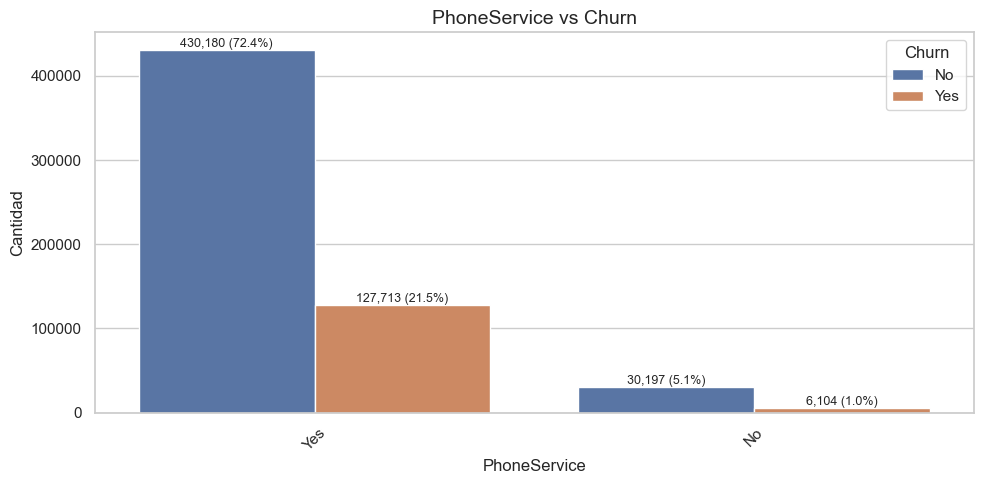

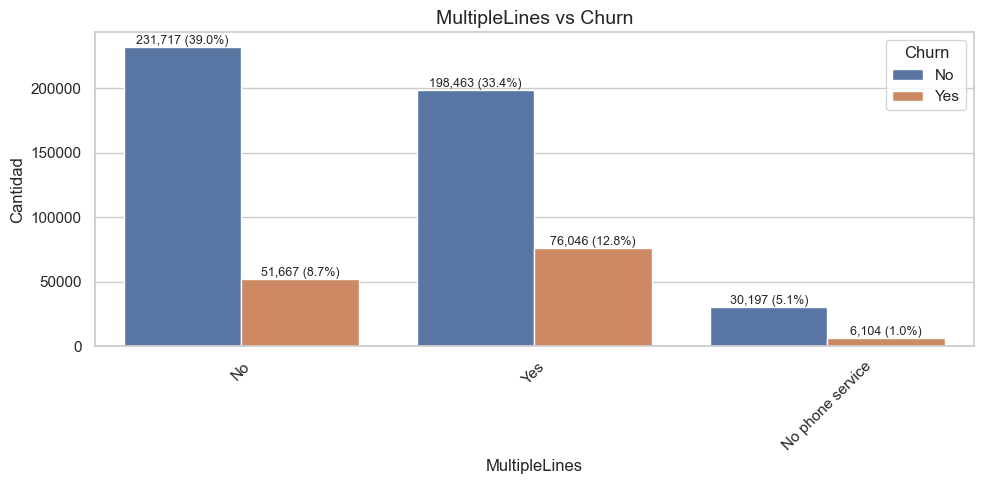

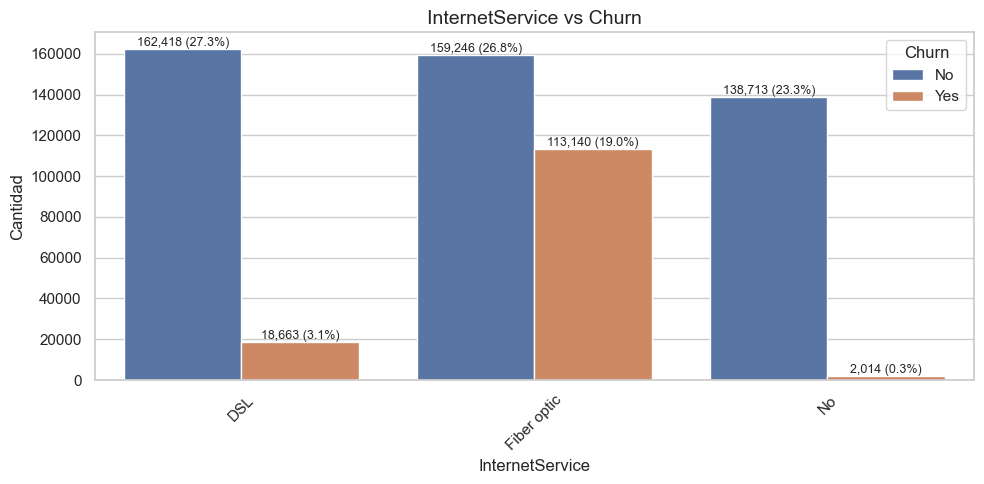

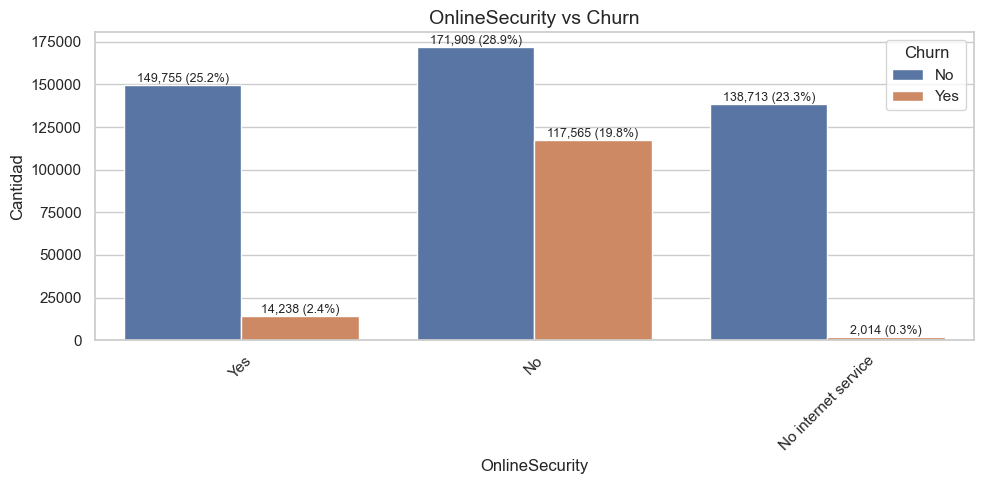

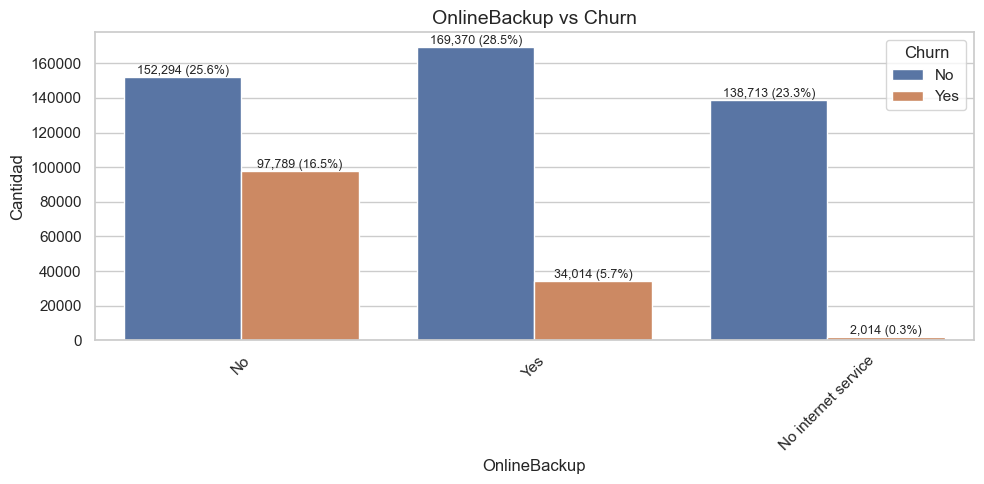

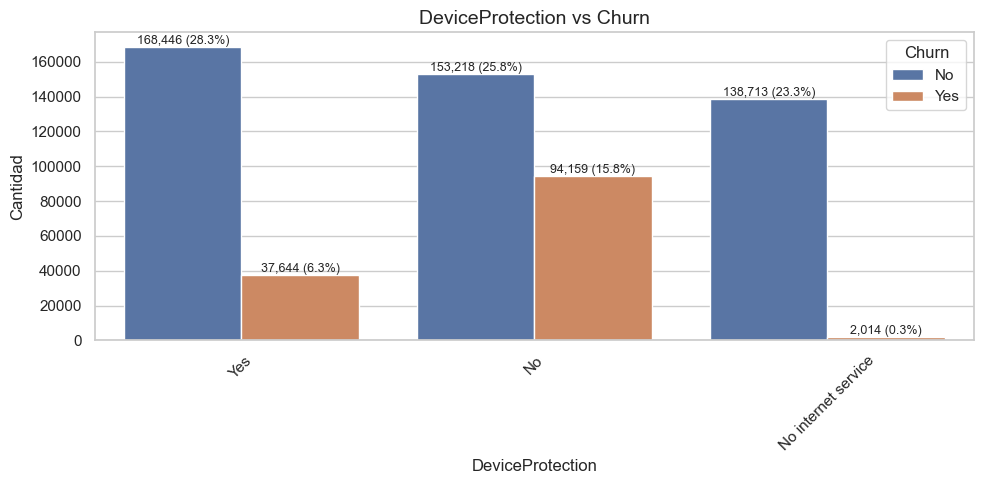

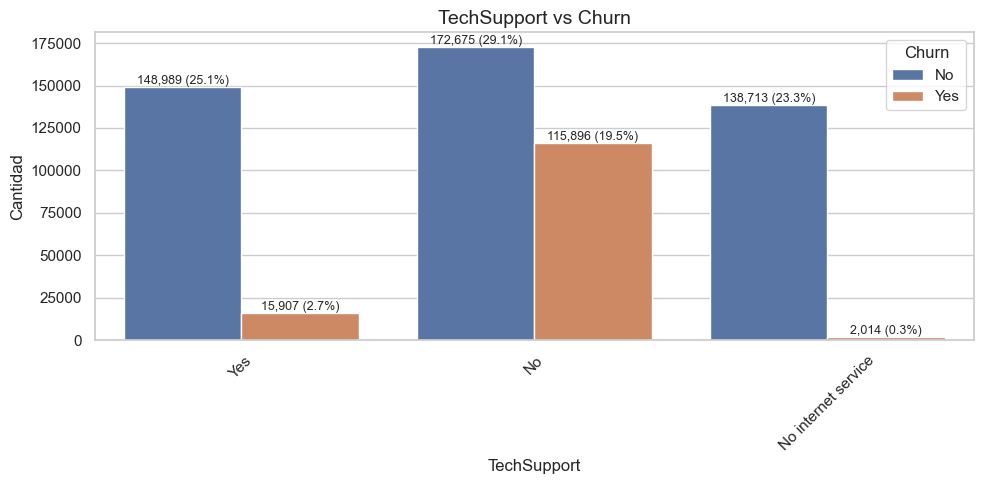

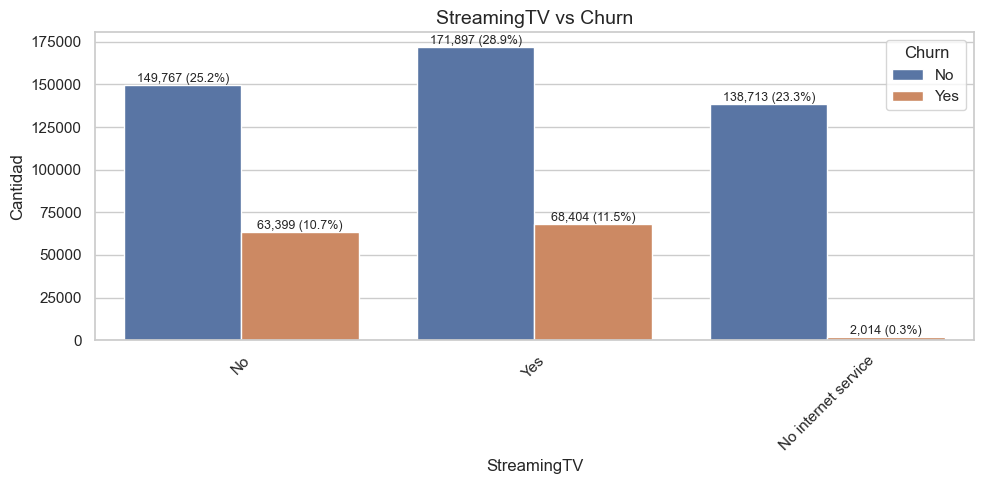

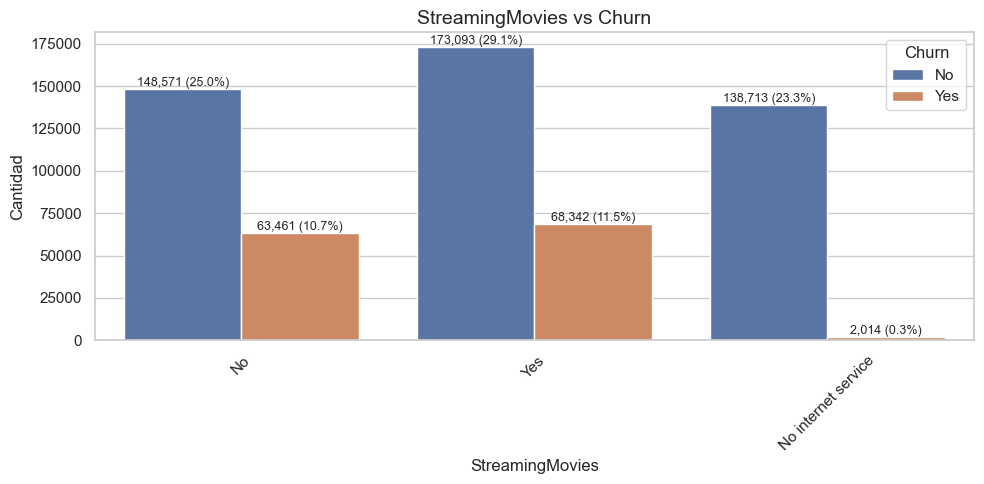

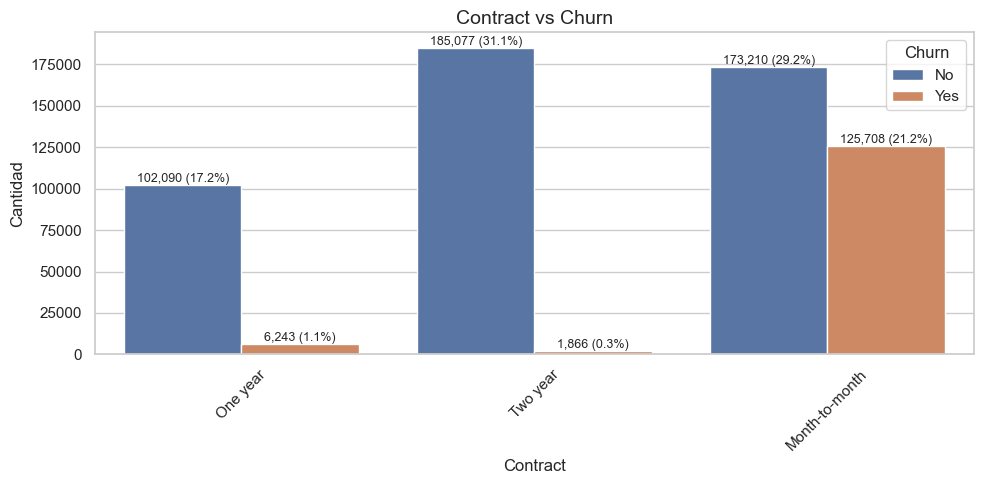

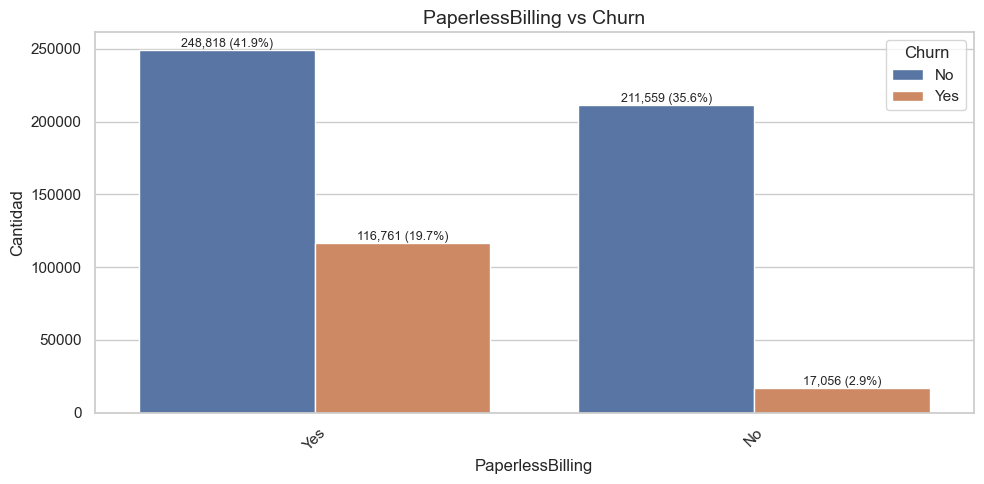

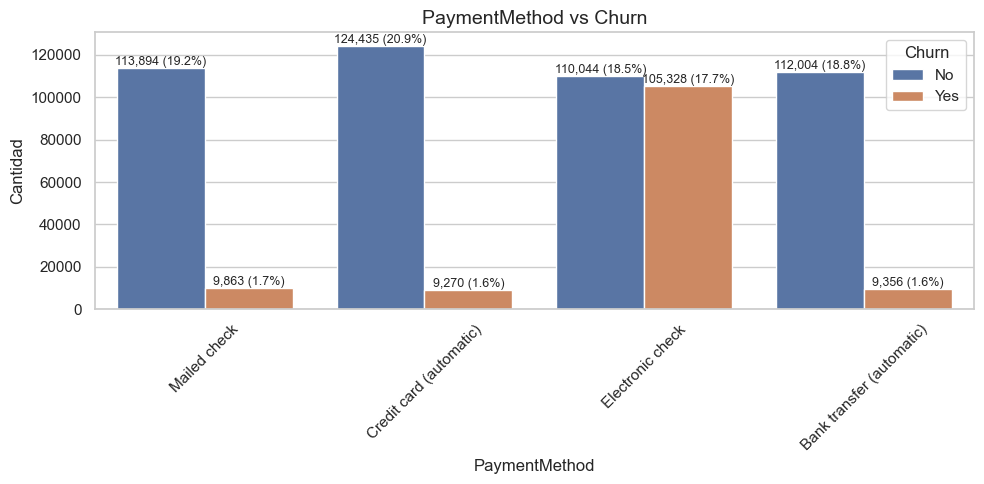

In [35]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    ax = sns.countplot(x=col, hue='Churn', data=df)
    total = len(df)

    # recorrer cada grupo de barras
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height == 0:
                continue
            pct = (height / total) * 100
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f'{int(height):,} ({pct:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

* **MultiplesLines** indica que las personas con multiples lineas tienen un 13% de probablidad de cancelar el servicio, este comportamiento podria ser dado a saturacion de servicios contratados.

* **InternetService** esta variable me parece bastante interesante al hacer la comparativa con la variable objetivo, mostrando que dentro de la población dada los que tienen el servicio de Fiber Optic son los que tienen mas probabilidad de cancelar el mismo, esto quizas es dado a alguna inconformidad con el servicio siento este el 10% de la población.

* **OnlineSecurity** esta variable Tambien refleja un patron anomalo, el 19.8% de la población tiene alta probabilidad de churn porque no tiene servicio de Seguridad contratado, esto podria referirse a un patron de fraude.

* **PaymentMethod** el grafico confirmo algo que me llama bastante la atención, la gran masa de clientes con probabilidad de churn tienen el método de pago **Electrinic Check** esto representa el 17.7% de la población, luego de esto todos los otros métodos de pago reflejan menos del 1.8% de probabilidad de churn.

* **Contract** al ver esta variable contra churn se confirma que los clientes que pagan mes a mes son los que tienen mayor probabilidad de irse, en cambio los que tienen contratos mas largos tienen menos probabilidad, lo ideal seria ver la posibilidad de realizar contratos mas largos para poder reducir esto.

* **TechSuport & DeviceProtection** son variables muy similares en comportamiento, las mimas reflejan una alta posibilidad de churn en clientes que no cuentan con estos servicios.

* **InternetService** el churn en los clientes con Fibra Optica es bastante alto, representando esto el 19% de la población, vale la pena destacar que este servicio es Premium cuando lo comparamos con el DSL.

* **Dependents** las ciudadanos sin dependientes reflejan el 20.3% de la población churn del dataset.

# Encoding De Variables Discretas (Encoding Binario, OHT, WoE)

In [36]:
binari_cols = ['Churn','gender','Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']
df_bi = df.copy()
for col in binari_cols:
    df_bi[col] = np.where(df_bi[col].astype(str).str.strip().str.lower() == 'yes', 1, 0)
print(df[binari_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Churn             594194 non-null  object
 1   gender            594194 non-null  object
 2   Partner           594194 non-null  object
 3   Dependents        594194 non-null  object
 4   PhoneService      594194 non-null  object
 5   MultipleLines     594194 non-null  object
 6   OnlineSecurity    594194 non-null  object
 7   OnlineBackup      594194 non-null  object
 8   DeviceProtection  594194 non-null  object
 9   TechSupport       594194 non-null  object
 10  StreamingTV       594194 non-null  object
 11  StreamingMovies   594194 non-null  object
 12  PaperlessBilling  594194 non-null  object
dtypes: object(13)
memory usage: 58.9+ MB
None


In [37]:
df_bi.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,1,29,1,0,DSL,1,0,1,1,0,0,One year,1,Mailed check,60.10,1653.85,0
1,0,0,1,1,58,1,0,DSL,1,1,0,1,1,0,Two year,0,Credit card (automatic),69.50,3778.20,0
2,0,0,1,0,58,1,1,Fiber optic,0,1,0,0,1,1,Month-to-month,1,Electronic check,100.40,5841.35,0
3,0,0,0,0,1,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,69.70,70.70,1
4,0,0,0,0,1,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.45,70.45,1


In [38]:
# Division de la Data

y = df['Churn'].map({'No': 0, 'Yes': 1})
x = df.drop('Churn', axis=1)

# funcion de KS
def ks_statistic(y_true, y_prob):
    df = pd.DataFrame({'y': y_true, 'prob': y_prob})
    df = df.sort_values('prob')

    df['cum_good'] = ((df['y'] == 0).cumsum())/ (df['y']== 0).sum()
    df['cum_bad'] = ((df['y'] == 1).cumsum())/ (df['y']== 1).sum()

    return np.max(np.abs(df['cum_good'] - df['cum_bad']))

ks_score = make_scorer(ks_statistic, needs_proba=True)


# WoE Manual


class ManualWOEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, epsilon=1e-6):
        self.epsilon = epsilon
        self.woe_dict_ = {}

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y)

        for col in X.columns:
            df = pd.DataFrame({col: X[col], 'target': y})
            grouped = df.groupby(col)['target'].agg(['count', 'sum'])
            grouped.columns = ['total', 'eventos']
            grouped['no_eventos'] = grouped['total'] - grouped['eventos']
            total_eventos = grouped['eventos'].sum()
            total_no_eventos = grouped['no_eventos'].sum()
            grouped['dist_eventos'] = grouped['eventos'] / total_eventos
            grouped['dist_no_eventos'] = grouped['no_eventos'] / total_no_eventos
            grouped['woe'] = np.log(
                (grouped['dist_no_eventos'] + self.epsilon) /
                (grouped['dist_eventos'] + self.epsilon)
            )
            self.woe_dict_[col] = grouped['woe'].to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            X[col] = X[col].map(self.woe_dict_[col]).fillna(0)
        return X


# Seleccion de Variables
categorical_cols = x.select_dtypes(include='object').columns.tolist()
numerical_cols = x.select_dtypes(exclude='object').columns.tolist()

# CV Config

cv = StratifiedKFold(n_splits=5, shuffle=True ,random_state=42)

# Pipelines

# OHE
ohe_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

# Target Encoding
tg_pipe = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', TargetEncoder(), categorical_cols),
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

# WoE Manual

woe_manual_pipeline = Pipeline([
    ('preprocess', ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', ManualWOEEncoder(), categorical_cols)
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

pipelines = {
    "OHE": ohe_pipe,
    "Target Encoding": tg_pipe,
    "WOE (Manual)": woe_manual_pipeline
}

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

results = []

for name, pipe in pipelines.items():
    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)
    y_prob = pipe.predict_proba(x_test)[:, 1]

    metrics = {
        'Model': name,
        'AUC': roc_auc_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'LogLoss': log_loss(y_test, y_prob),
        'KS': ks_statistic(y_test, y_prob)
    }

    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
results_df

,Model,AUC,Accuracy,F1,LogLoss,KS
0,OHE,0.908408,0.854450,0.670527,0.311849,0.665079
2,WOE (Manual),0.908297,0.854374,0.671076,0.312108,0.665472
1,Target Encoding,0.907981,0.854400,0.671002,0.312518,0.665992


A manera de prueba realice un test entre varios metodos de encoding, todos dieron casi el mismo resultado, de los que escogi utilizare el WoE.

## HetMap antes de Transformaciones.

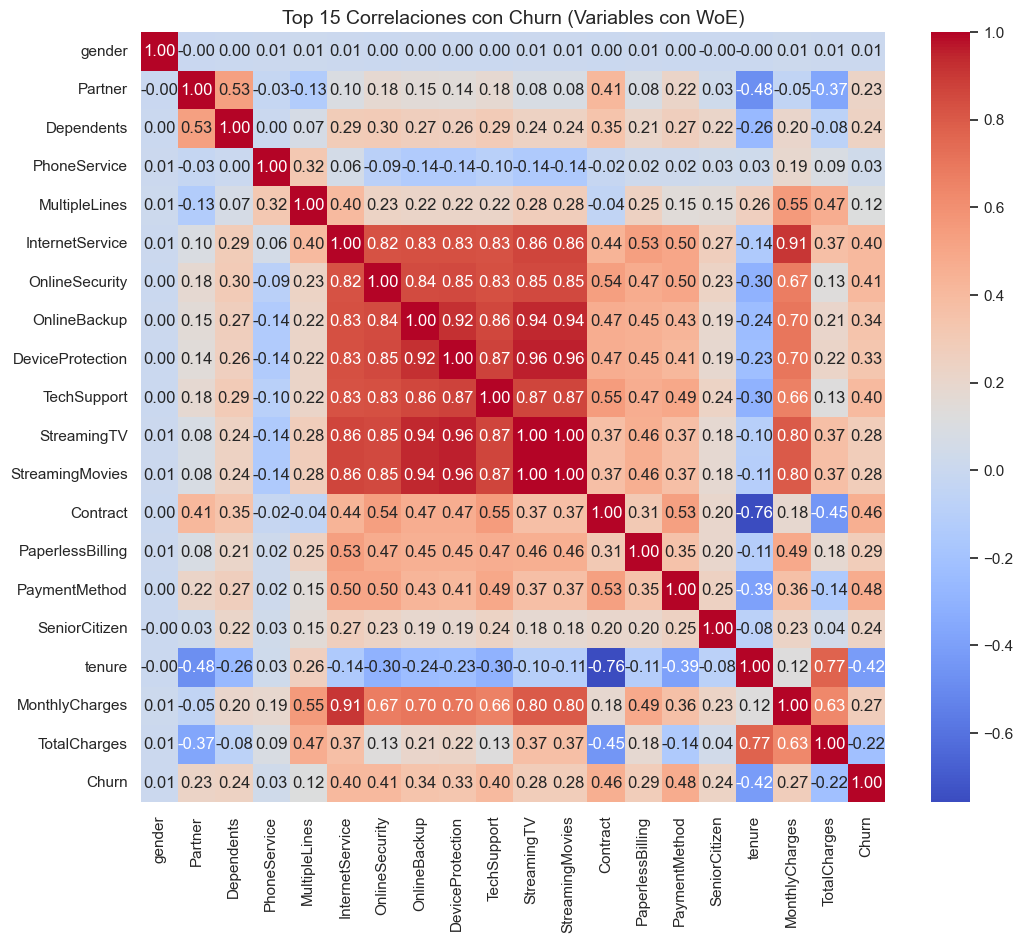

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from category_encoders import WOEEncoder

# 1. Aseguramos las variables predictoras (X) y la variable objetivo (y)
# Basado en tu código anterior, y debe ser numérica (0 y 1)
y = df['Churn'].map({'No': 0, 'Yes': 1}) if df['Churn'].dtype == 'object' else df['Churn']
X = df.drop('Churn', axis=1)

# 2. Identificamos automáticamente las columnas por su tipo
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# 3. Construimos el Preprocesador
# Aplicamos WoE a todas las categóricas y dejamos las numéricas tal cual
preprocessor = ColumnTransformer(
    transformers=[
        ('woe_enc', WOEEncoder(), cat_cols),
        ('keep_num', 'passthrough', num_cols)
    ],
    remainder='drop'
)

# 4. Ajustamos y transformamos (El WoE necesita ver X e y al mismo tiempo)
X_array = preprocessor.fit_transform(X, y)

# 5. ¡La Magia! Reconstruimos el DataFrame
# El ColumnTransformer pone primero las transformadas y luego el "passthrough"
columnas_ordenadas = cat_cols + num_cols
df_woe = pd.DataFrame(X_array, columns=columnas_ordenadas)

# 6. Agregamos el Target limpio para poder hacer las correlaciones
df_woe['Churn'] = y.reset_index(drop=True)

# 7. Graficamos el Heatmap Final
plt.figure(figsize=(12, 10))
correlacion_woe = df_woe.corr()

sns.heatmap(
    df_woe.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Top 15 Correlaciones con Churn (Variables con WoE)', fontsize=14)
plt.show()

Observaciones del HeatMap

realice un heatmap de las 10 variables con mejor correlacion con la variable objetivo, esto me permitira ver las correlaciones siendo mas objetivo, mostrando un HeatMap mas claro.

* **Contract** muestra una correlacion inversa de -0.45, mostrando que los contratos Month To Month tienen una tendencia alta a churn, **ternure** confirma la misma relación inversa que **contract** a menor tiempo de servicio mayor probabilidad de churn tienen los cliente, **OnlineSecurity** muestra una correlación inversa de -0.34, la misma no es una correlación fuerte pero muestra que los clientes que no tienen este servicio tienen una mayor probabilidad de churn, **TechSupport**  esta correlación inversa muestra que los clintes que no tienen Soporte técnico dentro de su paquete también tienen una gran probabilidad de churn,
**PaperlesBilling** muestra una correlación positiva de 0.29, considero que esta correlación es baja pero también forma parte del comportamiento del cliente, el mismo indica que los clientes que no reciben sus facturas tienen probabilidad de cancelar el servicio, **MonthlyChanges** se observa una correlación baja con respecto a la variable objetivo, de las correlaciones que podrían agregar mas valor al modelo son **OnlineBackup y Contract, Ternure y Contract**

## Promedio Target Por Categoria.


In [40]:
resultados_lista = []
categorical_to_analyze = [col for col in df.select_dtypes(include='object').columns if col not in ['customerID']]

for col in categorical_to_analyze:
    resumen = df.groupby(col)['Churn'].mean().reset_index()
    resumen.columns = ['Valor', 'Tasa de Churn (%)']
    resumen['Variable'] = col
    resumen['Tasa de Churn (%)'] = (resumen['Tasa de Churn (%)'] * 100).round(2)
    resultados_lista.append(resumen)

df_analisis_final = pd.concat(resultados_lista, ignore_index=True)
df_analisis_final = df_analisis_final[['Variable', 'Valor', 'Tasa de Churn (%)']]
df_analisis_final = df_analisis_final.sort_values(by='Tasa de Churn (%)', ascending=False)

df_analisis_final.head(15)

TypeError: agg function failed [how->mean,dtype->object]